# Document 3 — Dataset & Data Engineering
## Loan Default Risk Prediction System

**Student:** Narjiss Maimouni    
**Date:** April

---

### Note on Dataset
This notebook uses the Kaggle Loan Prediction dataset (614 rows) 
as a **practice environment** to develop and validate the full 
preprocessing pipeline.

The actual project dataset is the **"Give Me Some Credit"** dataset 
(150,000 applicants), currently being prepared using the same 
pipeline demonstrated here. Results on the full dataset will be 
presented in the final submission.

In [2]:
# Cell 1 - Imports 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv('loan_train.csv')
test  = pd.read_csv('loan_test.csv')

print(f"Train size: {train.shape}")
print(f"Test size: {test.shape}")


Train size: (614, 13)
Test size: (367, 12)


In [3]:
# cell 2 - Raw Dataset Overview (BEFORE any cleaning)
print("--- First 5 Rows ---")
print(train.head())

print("\n--- Shape & Data Types ---")
print(train.dtypes)

print("\n--- Basic Statistics ---")
print(train.describe())

print("\n--- Missing values (%) ---")
missing = (train.isnull().sum() / len(train) * 100).round(2)
print(missing[missing > 0].sort_values(ascending=False))

print("\n--- Class Distribution ---")
print(train['Loan_Status'].value_counts())
print(train['Loan_Status'].value_counts(normalize=True).round(3) * 100)

--- Fisrt 5 Rows ---
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  

In [ ]:
## Problems Identified in the Raw Dataset

1. **Missing Values**  7 columns contain missing data (0.49% to 8.14%)
2. **"3+" in Dependents** — string value that breaks numerical processing
3. **Useless column** — Loan_ID is just an identifier, not a feature
4. **Outliers** — ApplicantIncome (max=81,000 vs median=3,812), 
                   CoapplicantIncome, LoanAmount contain extreme values
5. **Categorical columns** — Gender, Married, Education, Self_Employed, 
                              Property_Area, Loan_Status stored as text
6. **Different scales** — Income in thousands, LoanAmount in hundreds, 
                           Credit_History is 0 or 1

In [4]:
# Cell 4 - Drop Loan_ID 
train = train.drop(columns=['Loan_ID'])
test = test.drop(columns=['Loan_ID'])

print("Loan_ID dropped.")
print(f"Train columns: {list(train.columns)}")

Loan_ID dropped.
Train columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [5]:
# Cell 5 - Fix "3+" in Dependents
# WHY I REPALCE +3 WITH 3 : 
 # Dependents means how many children or how many people financialy depend on the applicant . The values are: 1,2,3+
 # The problem is that "3+" is a string, not a number, and if we try to do math with it , NumPy will throw a TypeError.
 # I replace it with the number 3 because : The difference between 3 and 4+ dependents is not significant for loan risk.
train['Dependents'] = train['Dependents'].replace('3+', 3)
test['Dependents'] = test['Dependents'].replace('3+', 3)

train['Dependents'] = pd.to_numeric(train['Dependents'])
test['Dependents'] = pd.to_numeric(test['Dependents'])

print("Dependents unique values:", sorted(train['Dependents'].dropna().unique()))

Dependents unique values: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]


In [ ]:
## Step 3 - Handling missing values 

 Before filling any missing values, I analyzed each column individually to understand *why* the data is missing.
 This distinction is important because the filling strategy should reflect the real-world meaning behind each gap.

     ## 1 - Gender - 2.12% missing (13 people)
         The missing split is 8 approved, and 5 rejected.
         Nothing suspicious . These people probably just didn;t fill in this field on the application form. 
         Also, Gender should not legally influence loan approval in most countries
      Solution : Fill with Mode (Male)
     ## 2 - Married - 0.49% missing (3 people) 
         Only 3 people, and all the 3 were approved 
      Solution : Fill with Mode (Yes)
     ## 3 - Dependents - 2.44% missing (15 people)
         Nothing suspicious again. Someone just skipped this field .
         It could also mean they genuinely have 0 dependents and did not feel the need to write it .
      Solution : Fill with 0. skipping the dependents question most likely means none. More logically that using the median here. 
     ## 4 - Self_Employed - 5.21% missing (32 people)
         If we looked at the distribution : 500 people said No, and only 82 said Yes.
         People who are self_employed know they are; it is not something you forget. 
         People who left it blank most likely are not self_employed and just skipped it .
      Solution : Fill with Mode(No)
     ## 5 - LoanAmount - 3.58% missing (22 people)
         If we looked at hte data , most loans are arround 120 and 160, but some are 600.
         If we use the Mean , those who has 600 loans will pul the average up to maybe 180.
         Filling missing values with 180 when a person likely wanted just 130 , creates an Artificial debt.
      Solution : Fill with Median; the middle value of the data, resistant to extreme values. 
     ## 6 - Loan_Amount_Term - 2.28% missing (14 people)
         360 months (30 years) covers 83% of values.
      Solution : Fill with Mode(360) - standard term was implied , not recorded.
     ## 7 - Credit_History - 8.14% missing ()
         Credit_History is the most important feature in loan prediction.
         A missing value here does not mean a mistake , it means this person has never taken a loan before. 
         They have no history, good or bad. 

         Three options were considered:
          - Fill with **1 (Good)** → Too generous, assumes unknown = trustworthy
          - Fill with **0 (Bad)** → Unfair, penalizes new customers
          - Fill with **2 (Unknown)** → Honest — introduces a third category and lets the neural network learn 
            the relationship between no history and default risk.
      Solution : Option 3 = Add a new category - "Unknown" (value:2)

In [6]:
# Cell 6 - Handle Missing Values

#### --- Categorical Columns --- ###

# Gender: left blank on form, no deeper meaning -> Mode
train['Gender'] = train['Gender'].fillna(train['Gender'].mode()[0])
test['Gender'] = test['Gender'].fillna(test['Gender'].mode()[0])
# Married: only 3 missing -> Mode
train['Married'] = train['Married'].fillna(train['Married'].mode()[0])
test['Married'] = test['Married'].fillna(test['Married'].mode()[0])
# Self_Employed: blank likely means No, people know if they're self_employed -> Mode
train['Self_Employed'] = train['Self_Employed'].fillna(train['Self_Employed'].mode()[0])
test['Self_Employed'] = test['Self_Employed'].fillna(test['Self_Employed'].mode()[0])
# Dependents: skipping this field likely means zero dependents -> 0
train['Dependents'] = train['Dependents'].fillna(0)
test['Dependents'] = test['Dependents'].fillna(0)

### --- Numerical columns ---###

# LoanAmount: random gap, use Median (safer than Mean due to outliers)
train['LoanAmount'] = train['LoanAmount'].fillna(train['LoanAmount'].median())
test['LoanAmount'] = test['LoanAmount'].fillna(test['LoanAmount'].median())
# Loan_Amount_Term: 83% are 360, blank = standard term assumed -> Mode 
train['Loan_Amount_Term'] = train['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].mode()[0])
test['Loan_Amount_Term'] = test['Loan_Amount_Term'].fillna(test['Loan_Amount_Term'].mode()[0])
# Credit_History: missing = new customer
# Introduce thirs category: 2 = Unknown
train['Credit_History'] = train['Credit_History'].fillna(2)
test['Credit_History'] = test['Credit_History'].fillna(2)

### --- Verify --- ###
print("Missing calues remaining:")
print(train.isnull().sum()[train.isnull().sum() > 0])
print("(empty output above = zero missing values ✓)")

Missing calues remaining:
Series([], dtype: int64)
(empty output above = zero missing values ✓)


In [ ]:
## Step 4 - Outlier Treatment (Log Transformation)

### The Problem : 
     Three columns contain extreme values that distort the data: 
      . ApplicantIncome : 3,812 (Median) | 81,000 (Max) | 50 (Outliers)
      . CoapplicantIncome : 1,188 (Median) | 41,667 (Max) | 18 (outliers)
      . LoanAmount : 128 (Median) | 700 (Max) | 39(Outliers)
     One applicant earns 81,000 while the typical applicant earns 3,812. 
     When we scale later . this one person compress everyone else into a tiny range. 
     The model sees almost no difference between them.

### The Solution : Log Transformation
     Log transformation compress large numbers without deleting them.
     Example with ApplicantIncome :   - Raw value: 81,000 -> log1p -> 11.30
                                      - Raw value: 3,812 -> log1p -> 8.25
     The extreme gap (81.000 | 3.812) becomes a manageable gap (11.30 | 8.25) 

### Why we use log1p and not log ?
     we use np.log10() which means log(1 + value) instead of log(value) 
     to protect against one edge case : log(0) because is mathematically undefined 
                                        log1p(0) = log(1) = 0  (safe)
     CoapplicantIncome has many zero values (applicants with no co-applicant); so this protection is necessary.

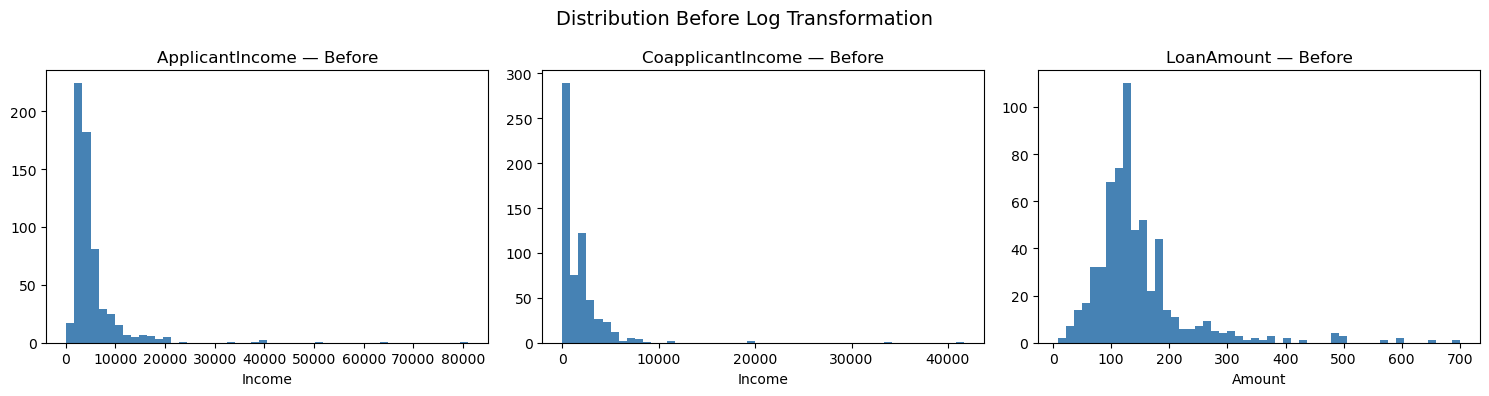

In [7]:
# Cell 7 — Outlier Visualization (Before Log Transformation)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(train['ApplicantIncome'], bins=50, color='steelblue')
axes[0].set_title('ApplicantIncome — Before')
axes[0].set_xlabel('Income')

axes[1].hist(train['CoapplicantIncome'], bins=50, color='steelblue')
axes[1].set_title('CoapplicantIncome — Before')
axes[1].set_xlabel('Income')

axes[2].hist(train['LoanAmount'], bins=50, color='steelblue')
axes[2].set_title('LoanAmount — Before')
axes[2].set_xlabel('Amount')

plt.suptitle('Distribution Before Log Transformation', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Cell 8 - Log Transformation 
# np.log1p = log(1 + value) — safe for zero values

train['ApplicantIncome'] = np.log1p(train['ApplicantIncome'])
train['CoapplicantIncome'] = np.log1p(train['CoapplicantIncome'])
train['LoanAmount'] = np.log1p(train['LoanAmount'])

test['ApplicantIncome'] = np.log1p(test['ApplicantIncome'])
test['CoapplicantIncome'] = np.log1p(test['CoapplicantIncome'])
test['LoanAmount'] = np.log1p(test['LoanAmount'])

print("Log transformation applied to: ApplicantIncome, CoapplicantIncome, LoanAmount")

Log transformation applied to: ApplicantIncome, CoapplicantIncome, LoanAmount


In [9]:
print(train['ApplicantIncome'].min(), train['ApplicantIncome'].max())
print(train['LoanAmount'].min(), train['LoanAmount'].max())

5.017279836814924 11.302216779257382
2.302585092994046 6.55250788703459


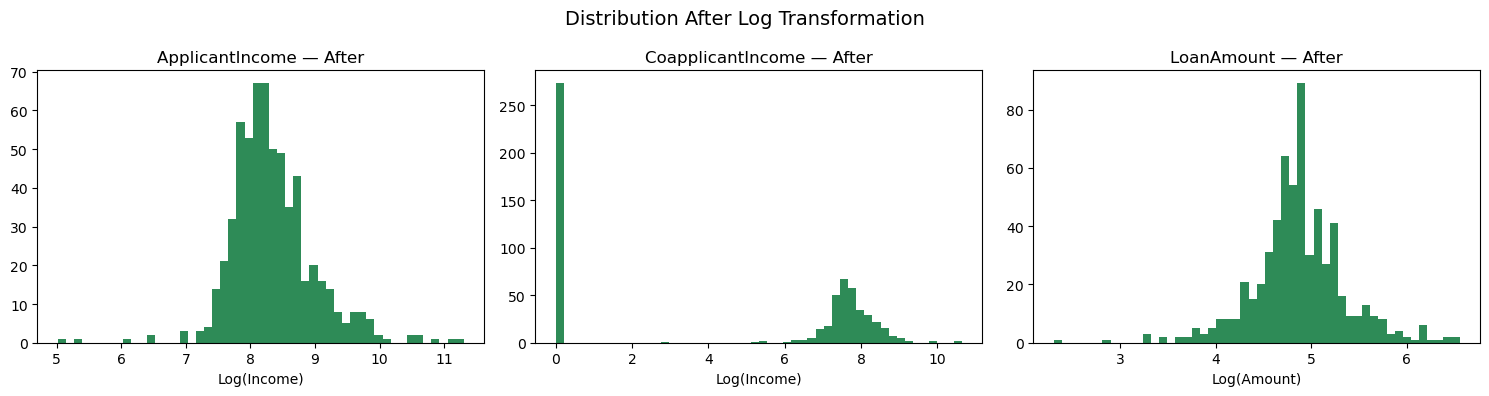

In [10]:
# Cell 9 — Outlier Visualization (After Log Transformation)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(train['ApplicantIncome'], bins=50, color='seagreen')
axes[0].set_title('ApplicantIncome — After')
axes[0].set_xlabel('Log(Income)')

axes[1].hist(train['CoapplicantIncome'], bins=50, color='seagreen')
axes[1].set_title('CoapplicantIncome — After')
axes[1].set_xlabel('Log(Income)')

axes[2].hist(train['LoanAmount'], bins=50, color='seagreen')
axes[2].set_title('LoanAmount — After')
axes[2].set_xlabel('Log(Amount)')

plt.suptitle('Distribution After Log Transformation', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# Cell 10 — Label Encoding for Binary Columns

# Neiral Network only unnderstand numbers, not text. 
#so we use Label Encoding to converts text categories into numbers.
# These columns have only 2 options so we safely map them to 0 and 1
# (For columns with 3+ unordered categories, we use One-Hot Encoding instead)

binary_maps = {
    'Gender'      : {'Male': 1, 'Female': 0},
    'Married'     : {'Yes': 1, 'No': 0},
    'Education'   : {'Graduate': 1, 'Not Graduate': 0},
    'Self_Employed': {'Yes': 1, 'No': 0},
    'Loan_Status' : {'Y': 1, 'N': 0}
}

for col, mapping in binary_maps.items():
    train[col] = train[col].map(mapping)

# Apply same to test (except Loan_Status — test has no answers)
for col, mapping in binary_maps.items():
    if col in test.columns:
        test[col] = test[col].map(mapping)

print("Label encoding applied:")
for col in binary_maps.keys():
    if col in train.columns:
        print(f"  {col}: {train[col].unique()}")

Label encoding applied:
  Gender: [1 0]
  Married: [0 1]
  Education: [1 0]
  Self_Employed: [0 1]
  Loan_Status: [1 0]


In [12]:
# Cell 11 — One-Hot Encoding (Property_Area + Credit_History)
# Property_Area: 3 unordered locations — Rural, Semiurban, Urban
# Credit_History: 3 categories (0=Bad, 1=Good, 2=Unknown — no ordering)

# Why NOT Label Encoding here?
  # Label encoding would give: Rural=0, Semiurban=1, Urban=2
  # The model would think Urban(2) > Semiurban(1) > Rural(0) - which is wrong. (locations have no ordering between them)
# One-Hot Encoding fixes this problem by creating separeat columns:
  # is_Semiurban: 0 or 1
  # is_Urban: 0 or 1
  # if both are 0 the model knows it must be Rural.

train = pd.get_dummies(train, columns=['Property_Area', 'Credit_History'], drop_first=True)
test  = pd.get_dummies(test,  columns=['Property_Area', 'Credit_History'], drop_first=True)
# why we use drop_first=True ? 
  # W don't need a Rural column - because if is_Semiurban=0 and is_Urban=0 , we already know it's Rural.
  # keeping it would be redundant information.
# same logic applies to Credit_History 

print("One-Hot Encoding applied to: Property_Area, Credit_History")
print(f"New columns: {[c for c in train.columns if 'Property_Area' in c or 'Credit_History' in c]}")
print(f"Train shape now: {train.shape}")

One-Hot Encoding applied to: Property_Area, Credit_History
New columns: ['Property_Area_Semiurban', 'Property_Area_Urban', 'Credit_History_1.0', 'Credit_History_2.0']
Train shape now: (614, 14)


In [13]:
print(train.columns.tolist())

['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Loan_Status', 'Property_Area_Semiurban', 'Property_Area_Urban', 'Credit_History_1.0', 'Credit_History_2.0']


In [14]:
# Cell 12 — Verify all columns are now numerical
print("=== Data Types After Encoding ===")
print(train.dtypes)
print() 
print("=== Any non-numeric columns left? ===")
non_numeric = train.select_dtypes(include='object').columns.tolist()
if len(non_numeric) == 0:
    print("None — all columns are numerical ✓")
else:
    print(f"Still text: {non_numeric}")

=== Data Types After Encoding ===
Gender                       int64
Married                      int64
Dependents                 float64
Education                    int64
Self_Employed                int64
ApplicantIncome            float64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Loan_Status                  int64
Property_Area_Semiurban       bool
Property_Area_Urban           bool
Credit_History_1.0            bool
Credit_History_2.0            bool
dtype: object

=== Any non-numeric columns left? ===
None — all columns are numerical ✓


In [15]:
 # Convert bool columns to integer (True→1, False→0)
bool_cols = train.select_dtypes(include='bool').columns
train[bool_cols] = train[bool_cols].astype(int)
test[bool_cols]  = test[bool_cols].astype(int)

print("Bool columns converted to int:")
print(train[bool_cols].dtypes)

Bool columns converted to int:
Property_Area_Semiurban    int64
Property_Area_Urban        int64
Credit_History_1.0         int64
Credit_History_2.0         int64
dtype: object


In [16]:
#Dependents should be a whole number (0, 1, 2, 3) not a decimal. 
#This happened because pandas automatically makes a column float when it contains missing values. 
#Since we already filled the missing values, we can safely convert it 
train['Dependents'] = train['Dependents'].astype(int)
test['Dependents']  = test['Dependents'].astype(int)

print("Dependents converted to int ✓")

Dependents converted to int ✓


In [17]:
print(train.dtypes)

Gender                       int64
Married                      int64
Dependents                   int64
Education                    int64
Self_Employed                int64
ApplicantIncome            float64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Loan_Status                  int64
Property_Area_Semiurban      int64
Property_Area_Urban          int64
Credit_History_1.0           int64
Credit_History_2.0           int64
dtype: object


In [18]:
# Cell 13 - MinMax Scaling (Normalization)

# WHY DO WE SCALE?
 # Our columns currently live on very different numerical ranges:
   # ApplicantIncome   → thousands (150 to 81,000)
   # LoanAmount        → hundreds (9 to 700)
   # Loan_Amount_Term  → tens (12 to 480)
   # Credit_History    → 0 or 1

# A neural network learns by adjusting weights based on the size of numbers.
# If Income is 5,849 and Credit_History is 1,the model will pay enormous attention to Income 
# simply because its number is bigger, not because it is actually more important.
# Scaling fixes this by bringing everything into the same range: 0 to 1.
# Now the model evaluates each feature fairly.

# Formula : X' = ( X - min ) / ( max - min )
# Compresses every value into the range [0,1]
# Only applied to continuous numerical columns
# Encoded binary columns already between 0 and 1 - no scaling needed

columns_to_scale = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

# an empty dictionnary to save the min and max values from Train - we gonna need it later
# we will need these exact values later in the FastAPI to scale new incoming data
scale_params = {}

for column in columns_to_scale:
    column_min = train[column].min()
    column_max = train[column].max()
    scale_params[column] = {'min' : column_min, 'max' : column_max}

    # Apply the relation to train
    train[column] = (train[column] - column_min) / (column_max - column_min)

    # Apply to test using train's min/max values 
    # Reason: in production , new data must be scaled using the same reference the model was trained on. 
    # using different values wold break the prediction.
    test[column] = (test[column] - column_min) / (column_max - column_min)

print("Scaling applied to:", columns_to_scale)
print()
print("--- Scale Parameters (saved for later) ---")
for column, params in scale_params.items():
    print(f"{column}: min={params['min']:.3f}, max={params['max']:.3f}")
    

Scaling applied to: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

--- Scale Parameters (saved for later) ---
ApplicantIncome: min=5.017, max=11.302
CoapplicantIncome: min=0.000, max=10.637
LoanAmount: min=2.303, max=6.553
Loan_Amount_Term: min=12.000, max=480.000


In [19]:
# Cell 14 - Final Verification
print("--- Shape ---")
print(f"Train: {train.shape}")
print(f"Test: {test.shape}")

print("\n--- Missing Values ---")
total_missing = train.isnull().sum().sum()
print(f"Total missing values: {total_missing} ✓" if total_missing == 0 else f"Still missing: {total_missing}")

print("\n--- Value Ranges ---")
print(train[columns_to_scale].describe().loc[['min', 'max']].round(3))

print("\n--- Final Column List ---")
print(train.columns.tolist())

print("\n--- Frist 5 Rows(clean Dataset) ---")
print(train.head())

--- Shape ---
Train: (614, 14)
Test: (367, 13)

--- Missing Values ---
Total missing values: 0 ✓

--- Value Ranges ---
     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term
min              0.0                0.0         0.0               0.0
max              1.0                1.0         1.0               1.0

--- Final Column List ---
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Loan_Status', 'Property_Area_Semiurban', 'Property_Area_Urban', 'Credit_History_1.0', 'Credit_History_2.0']

--- Frist 5 Rows(clean Dataset) ---
   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          1              0         0.581854   
1       1        1           1          1              0         0.543052   
2       1        1           0          1              1         0.475649   
3       1        1           0          0         